In [ ]:
!pip install opencv-python scikit-learn pandas matplotlib seaborn -q

In [ ]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier

Saving traffic2.webp to traffic2.webp


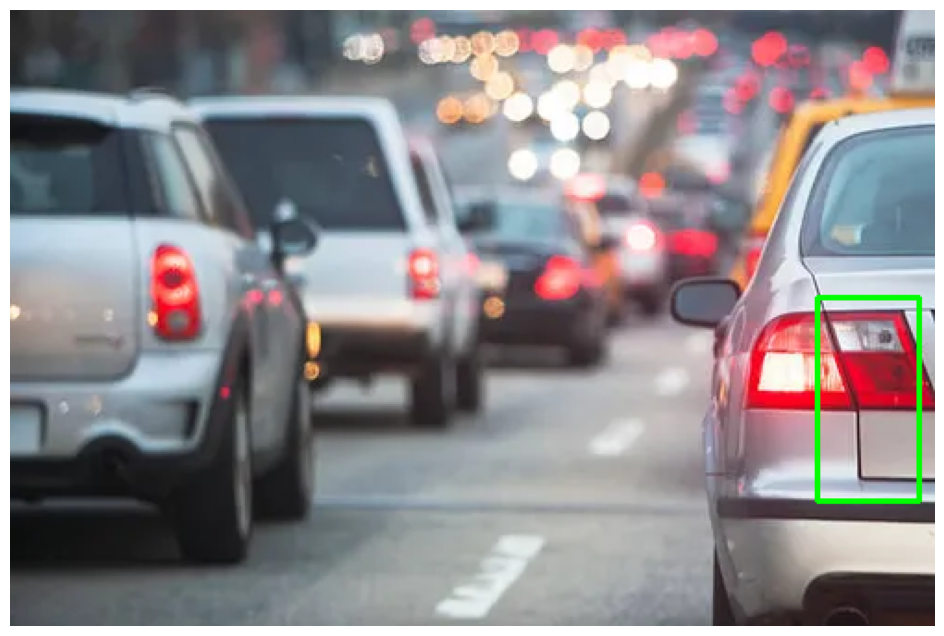

Vehicles Detected = 1


In [ ]:
from google.colab import files
uploaded = files.upload()

img_path = list(uploaded.keys())[0]

img = cv2.imread(img_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

car = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_fullbody.xml')

cars = car.detectMultiScale(gray, 1.1, 2)

count = len(cars)

for (x,y,w,h) in cars:
    cv2.rectangle(img,(x,y),(x+w,y+h),(0,255,0),2)

plt.figure(figsize=(12,8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

print("Vehicles Detected =", count)

In [ ]:
# Sample Traffic Dataset

traffic_data = {
    'vehicles':[5,10,15,25,35,45,60,75,90,110],
    'hour':[6,7,8,9,10,11,17,18,19,20],
    'day':[1,1,1,1,1,1,1,1,1,1],
    'traffic_level':[0,0,0,1,1,1,2,2,2,2]
}

# 0 = Low
# 1 = Medium
# 2 = High

df = pd.DataFrame(traffic_data)

df

,vehicles,hour,day,traffic_level
0,5,6,1,0
1,10,7,1,0
2,15,8,1,0
3,25,9,1,1
4,35,10,1,1
5,45,11,1,1
6,60,17,1,2
7,75,18,1,2
8,90,19,1,2
9,110,20,1,2


In [ ]:
X = df[['vehicles','hour','day']]
y = df['traffic_level']

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X,y)

RandomForestClassifier(random_state=42)

In [ ]:
# Example:
# count = vehicles detected from OpenCV

hour = 18      # current hour
day = 1        # weekday (1), weekend (0)

prediction = rf.predict([[count, hour, day]])[0]

levels = {
    0:"Low Traffic",
    1:"Medium Traffic",
    2:"High Traffic"
}

print("Predicted Traffic Status =", levels[prediction])

Predicted Traffic Status = High Traffic


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
from sklearn.metrics import accuracy_score

pred_train = rf.predict(X)
print("Model Accuracy =", accuracy_score(y, pred_train)*100, "%")

Model Accuracy = 100.0 %


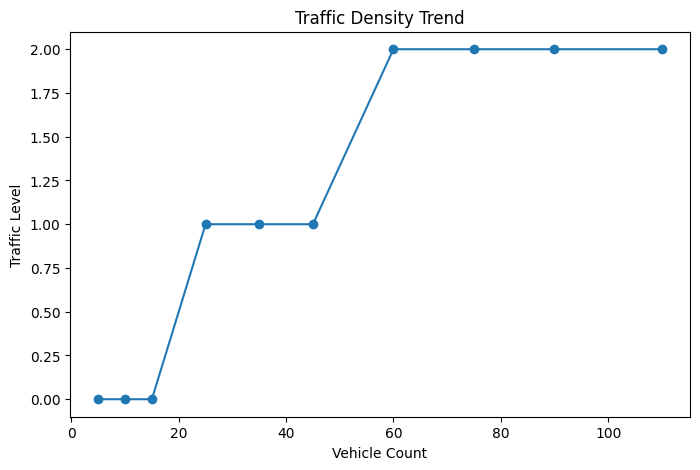

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(df['vehicles'], df['traffic_level'], marker='o')
plt.xlabel("Vehicle Count")
plt.ylabel("Traffic Level")
plt.title("Traffic Density Trend")
plt.show()

In [ ]:
pollution_data = {
    'vehicles':[10,20,30,40,50,60,70,80,90,100],
    'temperature':[25,26,27,28,29,30,31,32,33,34],
    'AQI':[40,52,60,72,85,95,110,125,140,155]
}

pollution_df = pd.DataFrame(pollution_data)

pollution_df

,vehicles,temperature,AQI
0,10,25,40
1,20,26,52
2,30,27,60
3,40,28,72
4,50,29,85
5,60,30,95
6,70,31,110
7,80,32,125
8,90,33,140
9,100,34,155


In [ ]:
X_pollution = pollution_df[['vehicles','temperature']]
y_pollution = pollution_df['AQI']

lr = LinearRegression()
lr.fit(X_pollution, y_pollution)

LinearRegression()

In [ ]:
temp = 32   # today's temperature

predicted_aqi = lr.predict([[count, temp]])[0]

print("Predicted AQI =", round(predicted_aqi,2))

Predicted AQI = 25.67


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
if predicted_aqi <= 50:
    status = "Good"
elif predicted_aqi <= 100:
    status = "Moderate"
elif predicted_aqi <= 150:
    status = "Unhealthy for Sensitive Groups"
else:
    status = "Unhealthy"

print("Air Quality Status =", status)

Air Quality Status = Good


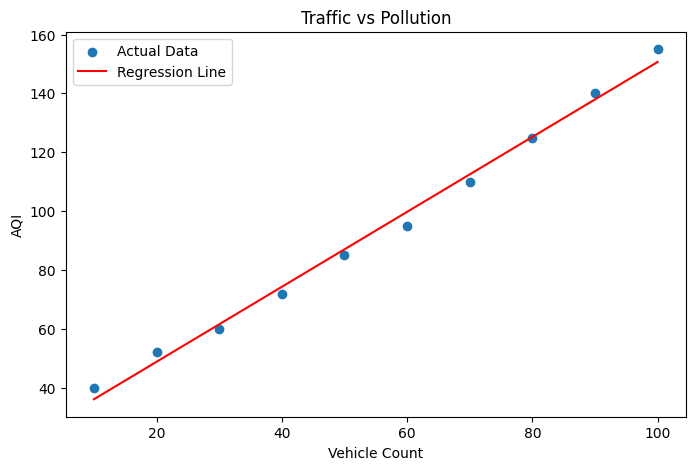

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(pollution_df['vehicles'], pollution_df['AQI'], label="Actual Data")
plt.plot(pollution_df['vehicles'],
         lr.predict(X_pollution),
         color='red',
         label="Regression Line")

plt.xlabel("Vehicle Count")
plt.ylabel("AQI")
plt.title("Traffic vs Pollution")
plt.legend()
plt.show()

In [ ]:
accident_data = {
    'traffic_level':[0,1,2,2,1,0,2,1,0,2],
    'rain':[0,0,1,1,0,0,1,1,0,1],
    'night':[0,1,1,0,1,0,1,0,0,1],
    'speed':[40,55,70,80,60,35,90,65,30,95],
    'risk':[0,1,2,2,1,0,2,1,0,2]
}

accident_df = pd.DataFrame(accident_data)

accident_df

,traffic_level,rain,night,speed,risk
0,0,0,0,40,0
1,1,0,1,55,1
2,2,1,1,70,2
3,2,1,0,80,2
4,1,0,1,60,1
5,0,0,0,35,0
6,2,1,1,90,2
7,1,1,0,65,1
8,0,0,0,30,0
9,2,1,1,95,2


In [ ]:
X_acc = accident_df[['traffic_level','rain','night','speed']]
y_acc = accident_df['risk']

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_acc, y_acc)

DecisionTreeClassifier(random_state=42)

In [ ]:
# Example Inputs
traffic_now = prediction   # from Step 4
rain_now = 1              # 1 = raining
night_now = 1             # 1 = night
speed_now = 75

risk_pred = dt.predict([[traffic_now, rain_now, night_now, speed_now]])[0]

risk_levels = {
    0:"Low Risk",
    1:"Medium Risk",
    2:"High Risk"
}

print("Accident Risk =", risk_levels[risk_pred])

Accident Risk = High Risk


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [ ]:
from sklearn.metrics import accuracy_score

train_pred = dt.predict(X_acc)

print("Model Accuracy =", accuracy_score(y_acc, train_pred)*100, "%")

Model Accuracy = 100.0 %


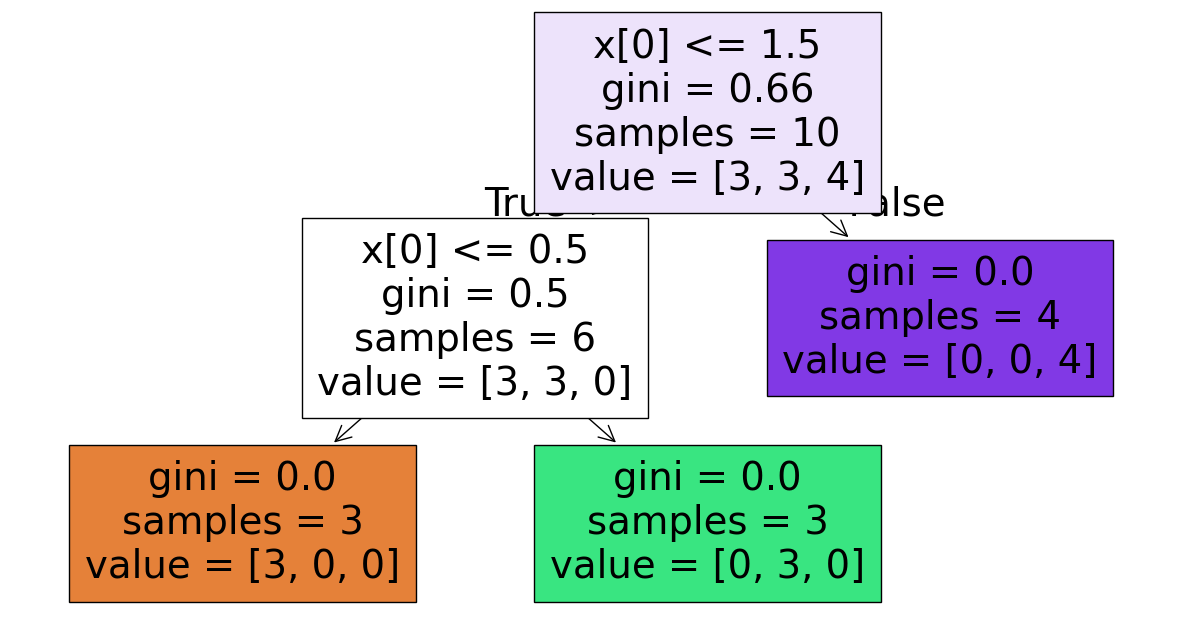

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(15,8))
plot_tree(dt, filled=True)
plt.show()

In [ ]:
print("===== SMART CITY REPORT =====")
print()

print("Traffic Status :", levels[prediction])
print("AQI Status     :", status)
print("Accident Risk  :", risk_levels[risk_pred])

print("\n===== RECOMMENDATIONS =====\n")

# Traffic Suggestions
if prediction == 2:
    print("🚦 Increase green signal timing on busy roads.")
    print("🚗 Suggest alternate routes via navigation apps.")
elif prediction == 1:
    print("🚘 Monitor traffic flow at intersections.")
else:
    print("✅ Traffic flow is smooth.")

# Pollution Suggestions
if predicted_aqi > 150:
    print("🌫️ Issue pollution alert to citizens.")
    print("🏭 Restrict heavy vehicles in peak hours.")
elif predicted_aqi > 100:
    print("🌿 Increase roadside plantation drives.")
    print("🚌 Encourage public transport.")
else:
    print("✅ Air quality is acceptable.")

# Accident Suggestions
if risk_pred == 2:
    print("⚠️ Deploy traffic police in this zone.")
    print("💡 Improve street lighting immediately.")
    print("🚧 Install warning boards / speed breakers.")
elif risk_pred == 1:
    print("🚨 Increase CCTV monitoring.")
else:
    print("✅ Accident risk currently low.")

===== SMART CITY REPORT =====

Traffic Status : High Traffic
AQI Status     : Good
Accident Risk  : High Risk

===== RECOMMENDATIONS =====

🚦 Increase green signal timing on busy roads.
🚗 Suggest alternate routes via navigation apps.
✅ Air quality is acceptable.
⚠️ Deploy traffic police in this zone.
💡 Improve street lighting immediately.
🚧 Install warning boards / speed breakers.


In [ ]:
summary = f"""
City Zone Analysis:

Traffic = {levels[prediction]}
AQI = {status}
Accident Risk = {risk_levels[risk_pred]}

Overall priority level should be monitored by municipal authorities.
"""

print(summary)


City Zone Analysis:

Traffic = High Traffic
AQI = Good
Accident Risk = High Risk

Overall priority level should be monitored by municipal authorities.



In [ ]:
final_report = pd.DataFrame({
    "Metric":[
        "Vehicles Detected",
        "Traffic Level",
        "Predicted AQI",
        "Air Quality Status",
        "Accident Risk"
    ],

    "Result":[
        count,
        levels[prediction],
        round(predicted_aqi,2),
        status,
        risk_levels[risk_pred]
    ]
})

final_report

,Metric,Result
0,Vehicles Detected,1
1,Traffic Level,High Traffic
2,Predicted AQI,25.67
3,Air Quality Status,Good
4,Accident Risk,High Risk


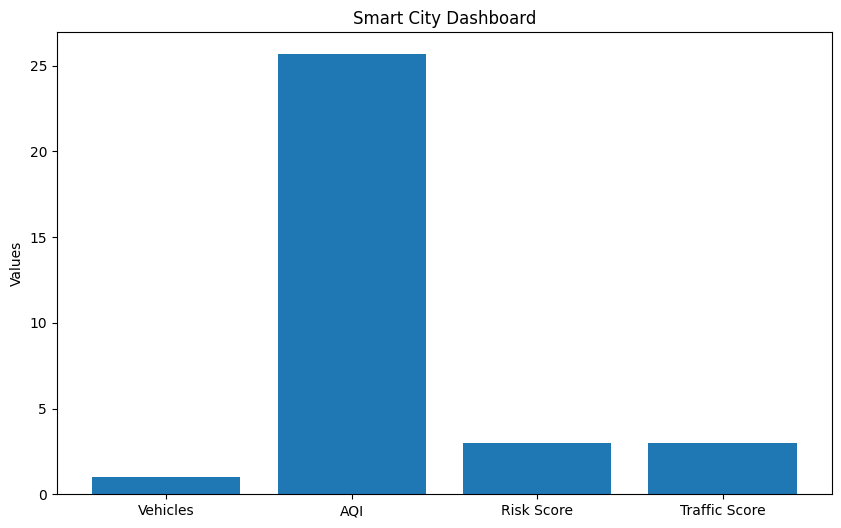

In [ ]:
dashboard_values = [
    count,
    predicted_aqi,
    risk_pred + 1,
    prediction + 1
]

dashboard_labels = [
    "Vehicles",
    "AQI",
    "Risk Score",
    "Traffic Score"
]

plt.figure(figsize=(10,6))
plt.bar(dashboard_labels, dashboard_values)

plt.title("Smart City Dashboard")
plt.ylabel("Values")
plt.show()

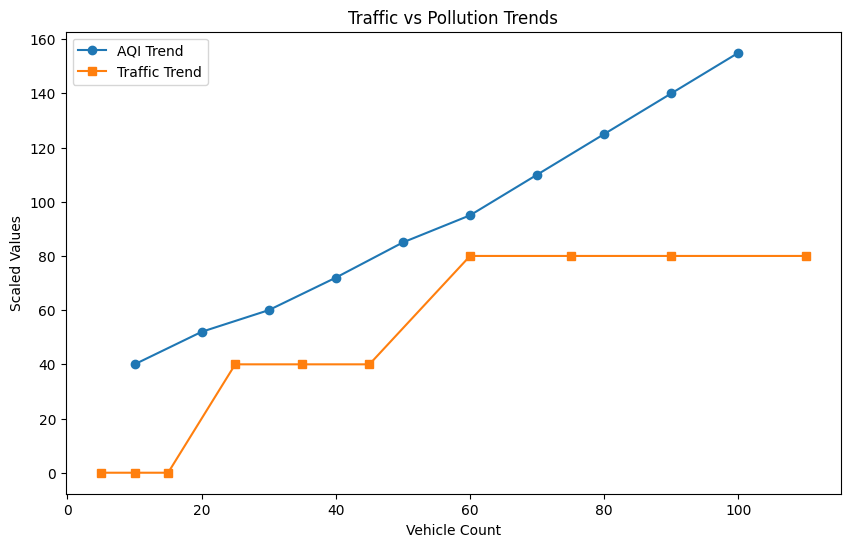

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(pollution_df['vehicles'],
         pollution_df['AQI'],
         marker='o',
         label="AQI Trend")

plt.plot(df['vehicles'],
         df['traffic_level']*40,
         marker='s',
         label="Traffic Trend")

plt.xlabel("Vehicle Count")
plt.ylabel("Scaled Values")
plt.title("Traffic vs Pollution Trends")
plt.legend()
plt.show()

In [ ]:
score = 100

if prediction == 2:
    score -= 30
elif prediction == 1:
    score -= 15

if predicted_aqi > 150:
    score -= 30
elif predicted_aqi > 100:
    score -= 15

if risk_pred == 2:
    score -= 30
elif risk_pred == 1:
    score -= 15

print("Overall Smart City Score =", score, "/100")

Overall Smart City Score = 40 /100


In [ ]:
if score >= 80:
    print("✅ City Zone Performing Well")
elif score >= 50:
    print("⚠️ Needs Improvement")
else:
    print("🚨 Critical Zone - Immediate Action Required")

🚨 Critical Zone - Immediate Action Required
